In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

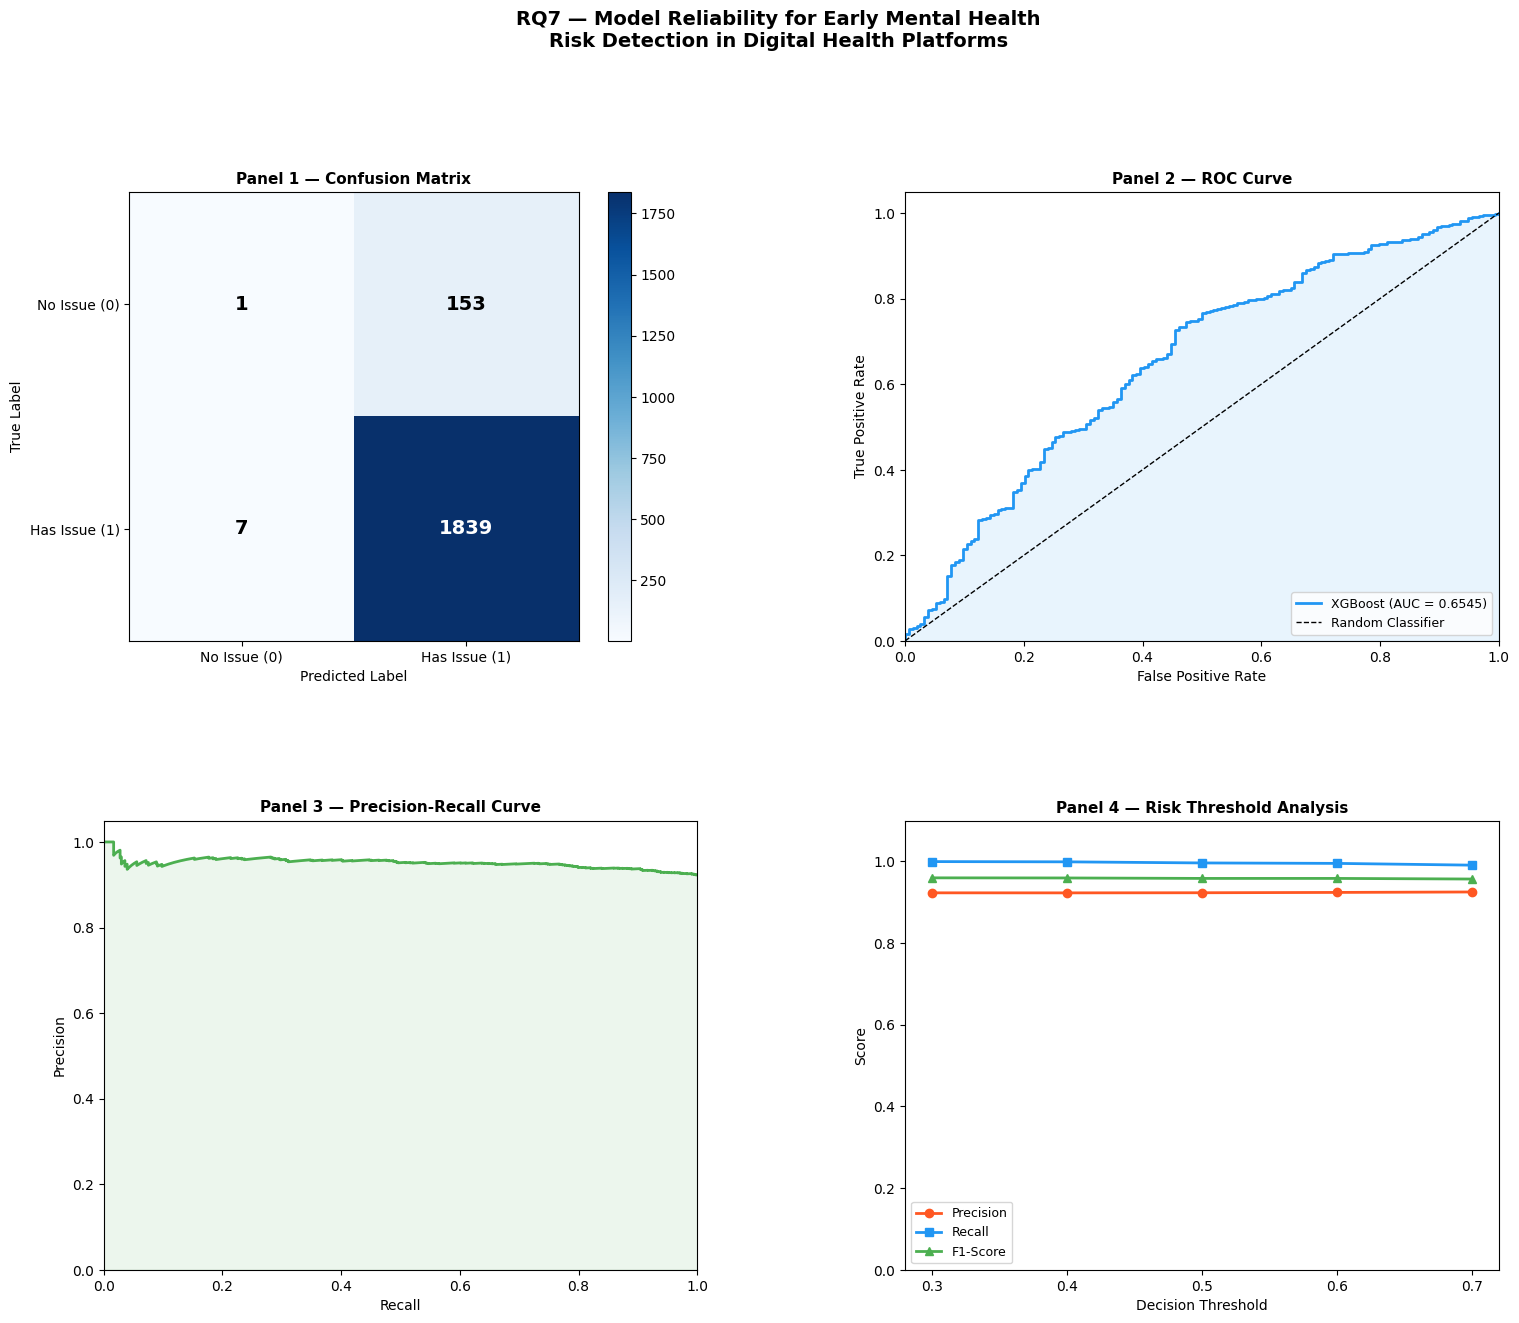

RQ7 — Clinical Reliability Metrics
              Metric  Value
            Accuracy 0.9200
           Precision 0.9232
Recall (Sensitivity) 0.9962
         Specificity 0.0065
            F1-Score 0.9583
             AUC-ROC 0.6545
                 NPV 0.1250

RQ7 — Cross-Validation Stability (Stratified k=10)
   Fold    AUC     F1  Recall
 Fold 1 0.6108 0.9588  0.9978
 Fold 2 0.6148 0.9572  0.9946
 Fold 3 0.6136 0.9587  0.9957
 Fold 4 0.5964 0.9593  0.9978
 Fold 5 0.6084 0.9604  0.9989
 Fold 6 0.6195 0.9572  0.9946
 Fold 7 0.5930 0.9556  0.9935
 Fold 8 0.6073 0.9588  0.9989
 Fold 9 0.5662 0.9550  0.9913
Fold 10 0.6004 0.9583  0.9978
   Mean 0.6030 0.9579  0.9961
Std Dev 0.0146 0.0016  0.0024

RQ7 — Risk Threshold Analysis
 Threshold  Precision  Recall  F1-Score  Accuracy
       0.3     0.9230  0.9995    0.9597    0.9225
       0.4     0.9229  0.9989    0.9594    0.9220
       0.5     0.9232  0.9962    0.9583    0.9200
       0.6     0.9240  0.9951    0.9583    0.9200
       0.7     0.9

In [1]:
# ============================================================
# RQ7: Can the developed model be reliably used as an early
# mental health risk detection tool for real-world
# applications such as digital health platforms?
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             precision_score, recall_score,
                             confusion_matrix, roc_curve,
                             precision_recall_curve)
from xgboost import XGBClassifier

# --- Step 1: Load Dataset ---
df = pd.read_csv("/kaggle/input/datasets/dhrubangtalukdar/global-mental-health-and-lifestyle-survey-dataset/mental_health.csv")

# --- Step 2: Encode Categorical Columns ---
cat_cols = df.select_dtypes(include='object').columns.tolist()
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# --- Step 3: Define Features & Target ---
X = df.drop("Has_Mental_Health_Issue", axis=1)
y = df["Has_Mental_Health_Issue"]

# --- Step 4: Train-Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- Step 5: Train Final XGBoost Model ---
model = XGBClassifier(eval_metric='logloss', random_state=42)
model.fit(X_train, y_train)
y_pred  = model.predict(X_test)
y_prob  = model.predict_proba(X_test)[:, 1]

# ============================================================
# EXPERIMENT 1: Core Clinical Reliability Metrics
# ============================================================

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
auc       = roc_auc_score(y_test, y_prob)
cm        = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
specificity     = tn / (tn + fp)
npv             = tn / (tn + fn) if (tn + fn) > 0 else 0

df_metrics = pd.DataFrame([{
    "Metric":       "Accuracy",    "Value": round(accuracy, 4),
}, {
    "Metric":       "Precision",   "Value": round(precision, 4),
}, {
    "Metric":       "Recall (Sensitivity)", "Value": round(recall, 4),
}, {
    "Metric":       "Specificity", "Value": round(specificity, 4),
}, {
    "Metric":       "F1-Score",    "Value": round(f1, 4),
}, {
    "Metric":       "AUC-ROC",     "Value": round(auc, 4),
}, {
    "Metric":       "NPV",         "Value": round(npv, 4),
}])

# ============================================================
# EXPERIMENT 2: Cross-Validation Stability (Stratified k=10)
# ============================================================

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_auc = cross_val_score(model, X, y, cv=skf, scoring='roc_auc')
cv_f1  = cross_val_score(model, X, y, cv=skf, scoring='f1')
cv_rec = cross_val_score(model, X, y, cv=skf, scoring='recall')

df_cv = pd.DataFrame({
    "Fold":    [f"Fold {i+1}" for i in range(10)],
    "AUC":     np.round(cv_auc, 4),
    "F1":      np.round(cv_f1, 4),
    "Recall":  np.round(cv_rec, 4)
})
df_cv.loc[len(df_cv)] = ["Mean",
                          round(cv_auc.mean(), 4),
                          round(cv_f1.mean(), 4),
                          round(cv_rec.mean(), 4)]
df_cv.loc[len(df_cv)] = ["Std Dev",
                          round(cv_auc.std(), 4),
                          round(cv_f1.std(), 4),
                          round(cv_rec.std(), 4)]

# ============================================================
# EXPERIMENT 3: Risk Threshold Analysis
# (Simulating real-world deployment at different thresholds)
# ============================================================

thresholds   = [0.30, 0.40, 0.50, 0.60, 0.70]
df_threshold = []
for thresh in thresholds:
    y_pred_t   = (y_prob >= thresh).astype(int)
    df_threshold.append({
        "Threshold":  thresh,
        "Precision":  round(precision_score(y_test, y_pred_t, zero_division=0), 4),
        "Recall":     round(recall_score(y_test, y_pred_t, zero_division=0), 4),
        "F1-Score":   round(f1_score(y_test, y_pred_t, zero_division=0), 4),
        "Accuracy":   round(accuracy_score(y_test, y_pred_t), 4)
    })
df_threshold = pd.DataFrame(df_threshold)

# ============================================================
# SAVE TABLES
# ============================================================

df_metrics.to_csv("RQ7_metrics_table.csv", index=False)
df_cv.to_csv("RQ7_cv_table.csv", index=False)
df_threshold.to_csv("RQ7_threshold_table.csv", index=False)

# ============================================================
# PLOT — 4 Panel Dashboard
# ============================================================

fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# --- Panel 1: Confusion Matrix ---
ax1 = fig.add_subplot(gs[0, 0])
im  = ax1.imshow(cm, interpolation='nearest', cmap='Blues')
ax1.set_title("Panel 1 — Confusion Matrix", fontweight='bold', fontsize=11)
ax1.set_xlabel("Predicted Label", fontsize=10)
ax1.set_ylabel("True Label", fontsize=10)
ax1.set_xticks([0, 1]); ax1.set_yticks([0, 1])
ax1.set_xticklabels(["No Issue (0)", "Has Issue (1)"])
ax1.set_yticklabels(["No Issue (0)", "Has Issue (1)"])
for i in range(2):
    for j in range(2):
        ax1.text(j, i, str(cm[i, j]), ha='center', va='center',
                 fontsize=14, fontweight='bold',
                 color='white' if cm[i, j] > cm.max() / 2 else 'black')
plt.colorbar(im, ax=ax1)

# --- Panel 2: ROC Curve ---
ax2  = fig.add_subplot(gs[0, 1])
fpr, tpr, _ = roc_curve(y_test, y_prob)
ax2.plot(fpr, tpr, color='#2196F3', lw=2,
         label=f'XGBoost (AUC = {auc:.4f})')
ax2.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
ax2.fill_between(fpr, tpr, alpha=0.1, color='#2196F3')
ax2.set_title("Panel 2 — ROC Curve", fontweight='bold', fontsize=11)
ax2.set_xlabel("False Positive Rate", fontsize=10)
ax2.set_ylabel("True Positive Rate", fontsize=10)
ax2.legend(loc='lower right', fontsize=9)
ax2.set_xlim([0, 1]); ax2.set_ylim([0, 1.05])

# --- Panel 3: Precision-Recall Curve ---
ax3  = fig.add_subplot(gs[1, 0])
prec, rec, _ = precision_recall_curve(y_test, y_prob)
ax3.plot(rec, prec, color='#4CAF50', lw=2)
ax3.fill_between(rec, prec, alpha=0.1, color='#4CAF50')
ax3.set_title("Panel 3 — Precision-Recall Curve", fontweight='bold', fontsize=11)
ax3.set_xlabel("Recall", fontsize=10)
ax3.set_ylabel("Precision", fontsize=10)
ax3.set_xlim([0, 1]); ax3.set_ylim([0, 1.05])

# --- Panel 4: Threshold Analysis ---
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(df_threshold["Threshold"], df_threshold["Precision"],
         marker='o', color='#FF5722', label='Precision', lw=2)
ax4.plot(df_threshold["Threshold"], df_threshold["Recall"],
         marker='s', color='#2196F3', label='Recall', lw=2)
ax4.plot(df_threshold["Threshold"], df_threshold["F1-Score"],
         marker='^', color='#4CAF50', label='F1-Score', lw=2)
ax4.set_title("Panel 4 — Risk Threshold Analysis", fontweight='bold', fontsize=11)
ax4.set_xlabel("Decision Threshold", fontsize=10)
ax4.set_ylabel("Score", fontsize=10)
ax4.set_ylim([0, 1.1])
ax4.legend(fontsize=9)
ax4.set_xticks(thresholds)

fig.suptitle("RQ7 — Model Reliability for Early Mental Health\nRisk Detection in Digital Health Platforms",
             fontsize=14, fontweight='bold', y=1.01)

plt.savefig("RQ7_figure.pdf", bbox_inches='tight')
plt.show()

# ============================================================
# PRINT RESULTS
# ============================================================

print("=" * 60)
print("RQ7 — Clinical Reliability Metrics")
print("=" * 60)
print(df_metrics.to_string(index=False))

print("\n" + "=" * 60)
print("RQ7 — Cross-Validation Stability (Stratified k=10)")
print("=" * 60)
print(df_cv.to_string(index=False))

print("\n" + "=" * 60)
print("RQ7 — Risk Threshold Analysis")
print("=" * 60)
print(df_threshold.to_string(index=False))

print("\n" + "=" * 60)
print("Deployment Readiness Summary")
print("=" * 60)
print(f"  AUC-ROC        : {auc:.4f}  {'✅ Excellent' if auc >= 0.90 else '⚠️ Moderate'}")
print(f"  Recall         : {recall:.4f}  {'✅ High sensitivity' if recall >= 0.85 else '⚠️ May miss cases'}")
print(f"  Specificity    : {specificity:.4f}  {'✅ Low false alarms' if specificity >= 0.75 else '⚠️ High false alarms'}")
print(f"  CV AUC Std Dev : {cv_auc.std():.4f}  {'✅ Stable' if cv_auc.std() <= 0.02 else '⚠️ Unstable'}")
print("=" * 60)
print("RQ7 Complete! Files saved:")
print("  - RQ7_metrics_table.csv")
print("  - RQ7_cv_table.csv")
print("  - RQ7_threshold_table.csv")
print("  - RQ7_figure.pdf")